In [602]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [603]:
df=pd.read_csv('house_price.csv')

In [604]:
df.isnull().sum()

ADDRESS                 0
SUBURB                  0
PRICE                   0
BEDROOMS                0
BATHROOMS               0
GARAGE               2478
LAND_AREA               0
FLOOR_AREA              0
BUILD_YEAR           3155
CBD_DIST                0
NEAREST_STN             0
NEAREST_STN_DIST        0
DATE_SOLD               0
POSTCODE                0
LATITUDE                0
LONGITUDE               0
NEAREST_SCH             0
NEAREST_SCH_DIST        0
NEAREST_SCH_RANK    10952
dtype: int64

In [605]:
df.rename(columns={'SUBURB':'Neighbour','CBD_DIST':'Cent_Busi_District_Dist'},inplace=True)

df.drop(columns=['ADDRESS','LATITUDE','LONGITUDE','NEAREST_SCH_RANK'],axis=1,inplace =True)

In [606]:
mod=int(df['GARAGE'].mode())
df['GARAGE'].fillna(mod,inplace=True)

C:\Users\nalla\AppData\Local\Temp\ipykernel_22224\3212792124.py:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  mod=int(df['GARAGE'].mode())
C:\Users\nalla\AppData\Local\Temp\ipykernel_22224\3212792124.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GARAGE'].fillna(mod,inplace=True)


In [607]:
df.isna().sum()

Neighbour                     0
PRICE                         0
BEDROOMS                      0
BATHROOMS                     0
GARAGE                        0
LAND_AREA                     0
FLOOR_AREA                    0
BUILD_YEAR                 3155
Cent_Busi_District_Dist       0
NEAREST_STN                   0
NEAREST_STN_DIST              0
DATE_SOLD                     0
POSTCODE                      0
NEAREST_SCH                   0
NEAREST_SCH_DIST              0
dtype: int64

In [608]:
df=df.dropna(subset=['BUILD_YEAR'])
df.reset_index(drop=True,inplace=True)

In [609]:
df.isnull().sum()

Neighbour                  0
PRICE                      0
BEDROOMS                   0
BATHROOMS                  0
GARAGE                     0
LAND_AREA                  0
FLOOR_AREA                 0
BUILD_YEAR                 0
Cent_Busi_District_Dist    0
NEAREST_STN                0
NEAREST_STN_DIST           0
DATE_SOLD                  0
POSTCODE                   0
NEAREST_SCH                0
NEAREST_SCH_DIST           0
dtype: int64

In [610]:
df.tail()

,Neighbour,PRICE,BEDROOMS,BATHROOMS,GARAGE,LAND_AREA,FLOOR_AREA,BUILD_YEAR,Cent_Busi_District_Dist,NEAREST_STN,NEAREST_STN_DIST,DATE_SOLD,POSTCODE,NEAREST_SCH,NEAREST_SCH_DIST
30496,Aubin Grove,423000,3,2,2.0,248,108,2011.0,24900,Cockburn Central Station,5700,05-2016\r,6164,ATWELL COLLEGE,3.607062
30497,Middle Swan,467000,4,2,2.0,400,132,2014.0,17100,Midland Station,2500,04-2015\r,6056,LA SALLE COLLEGE,1.116806
30498,South Fremantle,955000,3,2,1.0,200,127,1997.0,16000,Fremantle Station,1900,02-2019\r,6162,FREMANTLE COLLEGE,1.134956
30499,South Fremantle,1040000,4,3,2.0,292,245,2013.0,16100,Fremantle Station,1500,03-2016\r,6162,CHRISTIAN BROTHERS' COLLEGE,1.430350
30500,Girrawheen,295000,3,1,2.0,457,85,1974.0,12600,Warwick Station,4400,10-2016\r,6064,GIRRAWHEEN SENIOR HIGH SCHOOL,0.358494


In [611]:
df['GARAGE']=df['GARAGE'].astype(int)
df['BUILD_YEAR']=df['BUILD_YEAR'].astype(int)


In [612]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30501 entries, 0 to 30500
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Neighbour                30501 non-null  object 
 1   PRICE                    30501 non-null  int64  
 2   BEDROOMS                 30501 non-null  int64  
 3   BATHROOMS                30501 non-null  int64  
 4   GARAGE                   30501 non-null  int64  
 5   LAND_AREA                30501 non-null  int64  
 6   FLOOR_AREA               30501 non-null  int64  
 7   BUILD_YEAR               30501 non-null  int64  
 8   Cent_Busi_District_Dist  30501 non-null  int64  
 9   NEAREST_STN              30501 non-null  object 
 10  NEAREST_STN_DIST         30501 non-null  int64  
 11  DATE_SOLD                30501 non-null  object 
 12  POSTCODE                 30501 non-null  int64  
 13  NEAREST_SCH              30501 non-null  object 
 14  NEAREST_SCH_DIST      

In [613]:
pd.unique(df['Neighbour'])

array(['South Lake', 'Wandi', 'Camillo', 'Bellevue', 'Lockridge',
       'Mount Richon', 'Hilbert', 'Waikiki', 'Hamersley', 'Bayswater',
       'Carmel', 'Butler', 'Balga', 'Hammond Park', 'Wattle Grove',
       'Bull Creek', 'Bullsbrook', 'Maida Vale', 'Koongamia',
       'Mount Nasura', 'Forrestdale', 'Atwell', 'Ashby', 'Woodbridge',
       'Bicton', 'Singleton', 'Armadale', 'Kenwick', 'Hamilton Hill',
       'Port Kennedy', 'Glen Forrest', 'Secret Harbour', 'Herne Hill',
       'Gwelup', 'Harrisdale', 'North Fremantle', 'Quinns Rocks',
       'Spearwood', 'Parkwood', 'Tapping', 'Thornlie', 'Baldivis',
       'Kensington', 'Kiara', 'Menora', 'Southern River', 'Bibra Lake',
       'Swanbourne', 'The Vines', 'Stratton', 'North Beach', 'Haynes',
       'Madeley', 'Wembley Downs', 'Bentley', 'Manning', 'Queens Park',
       'Medina', 'Kalamunda', 'Merriwa', 'Aubin Grove', 'Karrinyup',
       'Gooseberry Hill', 'Darch', 'Hillarys', 'Alexander Heights',
       'St James', 'Bassendean', 'Ar

In [614]:
pd.unique(df['NEAREST_STN'])

array(['Cockburn Central Station', 'Kwinana Station', 'Challis Station',
       'Midland Station', 'Bassendean Station', 'Armadale Station',
       'Warnbro Station', 'Warwick Station', 'Bayswater Station',
       'Madding', 'Butler Station', 'Murdoch Station',
       'Success Hill Station', 'Joondalup Station', 'Woodbridge Station',
       'North Fremantle Station', 'Mandurah Station', 'Fremantle Station',
       'Thornlie Station', 'Currambine Station', 'Oats Street Station',
       'Mount Lawley Station', 'Swanbourne Station', 'Greenwood Station',
       'Glendalough Station', 'Welshpool Station',
       'Canning Bridge Station', 'Queens Park Station', 'Wellard Station',
       'Bull Creek Station', 'Kenwick Station', 'Edgewater Station',
       'Canning', 'Gosnells Station', 'Loch Street Station',
       'Maylands Station', 'Stirling Station', 'Subiaco Station',
       'Rockingham Station', 'Beckenham Station', 'Guildford Station',
       'Whitfords Station', 'Seaforth Station', 'A

In [615]:
pd.unique(df['NEAREST_SCH'])

array(['LAKELAND SENIOR HIGH SCHOOL', 'ATWELL COLLEGE',
       'KELMSCOTT SENIOR HIGH SCHOOL', 'SWAN VIEW SENIOR HIGH SCHOOL',
       'KIARA COLLEGE', 'ARMADALE SENIOR HIGH SCHOOL',
       'DALE CHRISTIAN SCHOOL', 'SOUTH COAST BAPTIST COLLEGE',
       'WARWICK SENIOR HIGH SCHOOL', 'CHISHOLM CATHOLIC COLLEGE',
       'CARMEL ADVENTIST COLLEGE', 'BUTLER COLLEGE',
       'BALGA SENIOR HIGH SCHOOL', 'REHOBOTH CHRISTIAN COLLEGE',
       'LEEMING SENIOR HIGH SCHOOL', 'HOLY CROSS COLLEGE',
       'DARLING RANGE SPORTS COLLEGE', 'SOWILO COMMUNITY HIGH SCHOOL',
       'CAREY BAPTIST COLLEGE', 'WANNEROO SECONDARY COLLEGE',
       'GOVERNOR STIRLING SENIOR HIGH SCHOOL', 'SANTA MARIA COLLEGE',
       'COMET BAY COLLEGE', 'HERITAGE COLLEGE PERTH', 'PORT SCHOOL',
       'WARNBRO COMMUNITY HIGH SCHOOL', 'HELENA COLLEGE',
       'SWAN CHRISTIAN COLLEGE', 'BALCATTA SENIOR HIGH SCHOOL',
       'IONA PRESENTATION COLLEGE',
       'PETER MOYES ANGLICAN COMMUNITY SCHOOL',
       'LYNWOOD SENIOR HIGH SCHOOL

In [616]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

names=['Neighbour','NEAREST_STN','NEAREST_SCH']
for i in names:
    df[i]=le.fit_transform(df[i])

In [617]:
df.head()

,Neighbour,PRICE,BEDROOMS,BATHROOMS,GARAGE,LAND_AREA,FLOOR_AREA,BUILD_YEAR,Cent_Busi_District_Dist,NEAREST_STN,NEAREST_STN_DIST,DATE_SOLD,POSTCODE,NEAREST_SCH,NEAREST_SCH_DIST
0,266,565000,4,2,2,600,160,2003,18300,17,1800,09-2018\r,6164,81,0.828339
1,289,365000,3,2,2,351,139,2013,26900,35,4900,02-2019\r,6167,8,5.524324
2,53,287000,3,1,1,719,86,1979,22600,12,1900,06-2015\r,6111,73,1.649178
3,32,255000,2,1,2,651,59,1953,17900,43,3600,07-2018\r,6056,144,1.571401
4,175,325000,4,1,2,466,131,1998,11200,2,2000,11-2016\r,6054,76,1.514922


In [618]:
dates=pd.to_datetime(df['DATE_SOLD'])
df['month_sold']=dates.dt.month
df['year_sold']=dates.dt.year

C:\Users\nalla\AppData\Local\Temp\ipykernel_22224\3961949163.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates=pd.to_datetime(df['DATE_SOLD'])


In [619]:
df.head()

,Neighbour,PRICE,BEDROOMS,BATHROOMS,GARAGE,LAND_AREA,FLOOR_AREA,BUILD_YEAR,Cent_Busi_District_Dist,NEAREST_STN,NEAREST_STN_DIST,DATE_SOLD,POSTCODE,NEAREST_SCH,NEAREST_SCH_DIST,month_sold,year_sold
0,266,565000,4,2,2,600,160,2003,18300,17,1800,09-2018\r,6164,81,0.828339,9,2018
1,289,365000,3,2,2,351,139,2013,26900,35,4900,02-2019\r,6167,8,5.524324,2,2019
2,53,287000,3,1,1,719,86,1979,22600,12,1900,06-2015\r,6111,73,1.649178,6,2015
3,32,255000,2,1,2,651,59,1953,17900,43,3600,07-2018\r,6056,144,1.571401,7,2018
4,175,325000,4,1,2,466,131,1998,11200,2,2000,11-2016\r,6054,76,1.514922,11,2016


In [620]:
df.drop('DATE_SOLD',axis=1,inplace=True)

In [621]:
X=df.drop('PRICE',axis=1)
y=df['PRICE']

In [622]:
X.head()

,Neighbour,BEDROOMS,BATHROOMS,GARAGE,LAND_AREA,FLOOR_AREA,BUILD_YEAR,Cent_Busi_District_Dist,NEAREST_STN,NEAREST_STN_DIST,POSTCODE,NEAREST_SCH,NEAREST_SCH_DIST,month_sold,year_sold
0,266,4,2,2,600,160,2003,18300,17,1800,6164,81,0.828339,9,2018
1,289,3,2,2,351,139,2013,26900,35,4900,6167,8,5.524324,2,2019
2,53,3,1,1,719,86,1979,22600,12,1900,6111,73,1.649178,6,2015
3,32,2,1,2,651,59,1953,17900,43,3600,6056,144,1.571401,7,2018
4,175,4,1,2,466,131,1998,11200,2,2000,6054,76,1.514922,11,2016


In [623]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30501 entries, 0 to 30500
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Neighbour                30501 non-null  int64  
 1   BEDROOMS                 30501 non-null  int64  
 2   BATHROOMS                30501 non-null  int64  
 3   GARAGE                   30501 non-null  int64  
 4   LAND_AREA                30501 non-null  int64  
 5   FLOOR_AREA               30501 non-null  int64  
 6   BUILD_YEAR               30501 non-null  int64  
 7   Cent_Busi_District_Dist  30501 non-null  int64  
 8   NEAREST_STN              30501 non-null  int64  
 9   NEAREST_STN_DIST         30501 non-null  int64  
 10  POSTCODE                 30501 non-null  int64  
 11  NEAREST_SCH              30501 non-null  int64  
 12  NEAREST_SCH_DIST         30501 non-null  float64
 13  month_sold               30501 non-null  int32  
 14  year_sold             

In [624]:
X['Age']=2025-X['BUILD_YEAR']
X.drop('BUILD_YEAR',axis=1,inplace=True)

In [625]:
X['No_of_rooms']=X['BATHROOMS']+X['BEDROOMS']

In [626]:
X.drop(columns=['BEDROOMS','BATHROOMS'],inplace=True)

In [627]:
X.corr()

,Neighbour,GARAGE,LAND_AREA,FLOOR_AREA,Cent_Busi_District_Dist,NEAREST_STN,NEAREST_STN_DIST,POSTCODE,NEAREST_SCH,NEAREST_SCH_DIST,month_sold,year_sold,Age,No_of_rooms
Neighbour,1.000000,0.002739,-0.021749,0.016266,0.072806,0.192669,0.044467,0.011862,0.121965,-0.017272,-0.012406,0.002213,0.044562,-0.000225
GARAGE,0.002739,1.000000,0.048986,0.188274,0.042009,-0.020873,0.100519,0.024781,-0.017302,0.087191,-0.001944,-0.012703,-0.040009,0.204767
LAND_AREA,-0.021749,0.048986,1.000000,0.068516,0.127172,0.027730,0.222721,0.034603,-0.004673,0.276957,0.006735,-0.154590,-0.002063,0.046260
FLOOR_AREA,0.016266,0.188274,0.068516,1.000000,0.016894,-0.041916,0.104945,-0.059623,-0.007936,0.118554,0.002234,-0.053720,-0.226872,0.620624
Cent_Busi_District_Dist,0.072806,0.042009,0.127172,0.016894,1.000000,-0.027822,0.438841,0.253496,0.035373,0.366224,0.005522,-0.048361,-0.270110,0.092659
NEAREST_STN,0.192669,-0.020873,0.027730,-0.041916,-0.027822,1.000000,0.038374,-0.036871,0.255064,-0.045031,0.002470,0.005953,0.129506,-0.057900
NEAREST_STN_DIST,0.044467,0.100519,0.222721,0.104945,0.438841,0.038374,1.000000,0.184221,-0.026833,0.620205,0.001260,-0.201761,-0.103350,0.085707
POSTCODE,0.011862,0.024781,0.034603,-0.059623,0.253496,-0.036871,0.184221,1.000000,-0.125249,0.108031,0.002727,-0.048851,-0.044095,-0.017613
NEAREST_SCH,0.121965,-0.017302,-0.004673,-0.007936,0.035373,0.255064,-0.026833,-0.125249,1.000000,0.013154,-0.013114,-0.033121,0.065110,-0.018327
NEAREST_SCH_DIST,-0.017272,0.087191,0.276957,0.118554,0.366224,-0.045031,0.620205,0.108031,0.013154,1.000000,-0.005141,-0.203346,-0.108719,0.089431


In [628]:
cols=list(X.columns)
cols

['Neighbour',
 'GARAGE',
 'LAND_AREA',
 'FLOOR_AREA',
 'Cent_Busi_District_Dist',
 'NEAREST_STN',
 'NEAREST_STN_DIST',
 'POSTCODE',
 'NEAREST_SCH',
 'NEAREST_SCH_DIST',
 'month_sold',
 'year_sold',
 'Age',
 'No_of_rooms']

In [629]:
# for i in cols:
#     plt.figure(figsize=(5,3))
#     sns.boxplot(X[i])
#     plt.show()

In [630]:
w=X.merge(y,left_index=True,right_index=True)
w

,Neighbour,GARAGE,LAND_AREA,FLOOR_AREA,Cent_Busi_District_Dist,NEAREST_STN,NEAREST_STN_DIST,POSTCODE,NEAREST_SCH,NEAREST_SCH_DIST,month_sold,year_sold,Age,No_of_rooms,PRICE
0,266,2,600,160,18300,17,1800,6164,81,0.828339,9,2018,22,6,565000
1,289,2,351,139,26900,35,4900,6167,8,5.524324,2,2019,12,5,365000
2,53,1,719,86,22600,12,1900,6111,73,1.649178,6,2015,46,4,287000
3,32,2,651,59,17900,43,3600,6056,144,1.571401,7,2018,72,3,255000
4,175,2,466,131,11200,2,2000,6054,76,1.514922,11,2016,27,5,325000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30496,12,2,248,108,24900,17,5700,6164,8,3.607062,5,2016,14,5,423000
30497,192,2,400,132,17100,43,2500,6056,79,1.116806,4,2015,11,6,467000
30498,264,1,200,127,16000,25,1900,6162,50,1.134956,2,2019,28,5,955000
30499,264,2,292,245,16100,25,1500,6162,28,1.430350,3,2016,12,7,1040000


<Axes: >

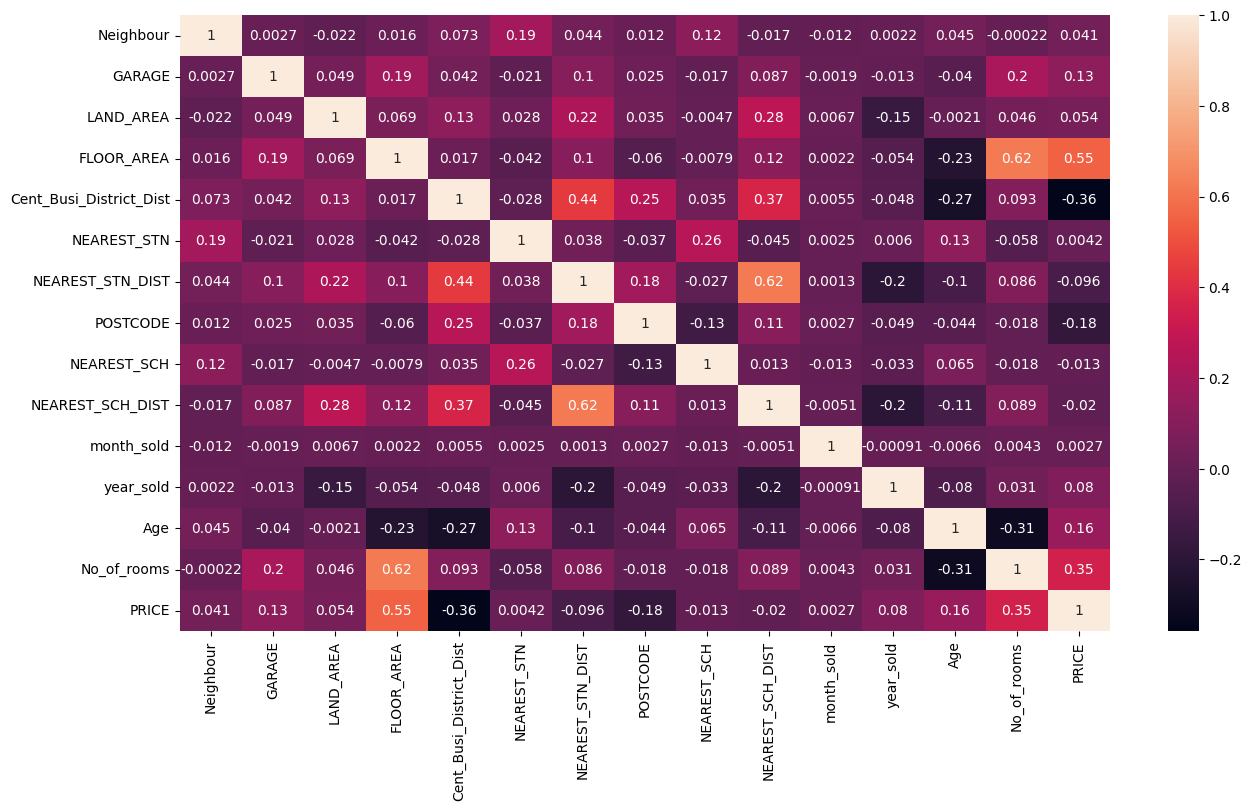

In [631]:
plt.figure(figsize=(15,8))
sns.heatmap(w.corr(),annot=True)

In [632]:
X.drop(columns=['Neighbour','NEAREST_STN'],inplace=True)

In [633]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [634]:
X_train.head()

,GARAGE,LAND_AREA,FLOOR_AREA,Cent_Busi_District_Dist,NEAREST_STN_DIST,POSTCODE,NEAREST_SCH,NEAREST_SCH_DIST,month_sold,year_sold,Age,No_of_rooms
12666,2,826,450,17900,3400,6020,119,0.558675,6,2018,32,8
18346,2,726,228,25700,3100,6027,111,0.954126,5,2019,29,6
3479,2,624,260,17100,7200,6065,82,1.264057,5,2019,20,7
29292,2,929,301,11300,3100,6150,92,1.461142,12,2018,37,6
20629,1,810,127,32000,3100,6167,51,0.520332,2,2017,65,4


In [653]:
len(X_train.columns)

12

In [635]:
X_train.reset_index(drop=True,inplace=True)
X_test.reset_index(drop=True,inplace=True)

In [636]:
X_train.shape

(24400, 12)

In [637]:
y_test.shape

(6101,)

In [638]:
X_test.head()

,GARAGE,LAND_AREA,FLOOR_AREA,Cent_Busi_District_Dist,NEAREST_STN_DIST,POSTCODE,NEAREST_SCH,NEAREST_SCH_DIST,month_sold,year_sold,Age,No_of_rooms
0,2,872,143,38200,510,6168,78,1.132209,9,2014,51,4
1,2,732,108,13900,7200,6064,82,2.297276,7,2016,37,6
2,2,662,187,26100,1300,6028,80,1.069190,6,2018,30,6
3,2,781,143,12000,1800,6022,154,1.414861,5,2016,48,5
4,2,412,150,26200,2400,6112,38,1.003240,8,2013,10,4


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
name=['LAND_AREA','FLOOR_AREA','Cent_Busi_District_Dist','NEAREST_SCH_DIST','NEAREST_STN_DIST','NEAREST_SCH']
X_train[name]=scaler.fit_transform(X_train[name])
X_test[name]=scaler.transform(X_test[name])

In [640]:
X_train.head()

,GARAGE,LAND_AREA,FLOOR_AREA,Cent_Busi_District_Dist,NEAREST_STN_DIST,POSTCODE,NEAREST_SCH,NEAREST_SCH_DIST,month_sold,year_sold,Age,No_of_rooms
0,2,-0.111378,3.693346,-0.154092,-0.243040,6020,0.871430,-0.725243,6,2018,32,8
1,2,-0.117394,0.618790,0.537704,-0.310982,6027,0.705460,-0.492085,5,2019,29,6
2,2,-0.123530,1.061969,-0.225046,0.617555,6065,0.103817,-0.309351,5,2019,20,7
3,2,-0.105182,1.629793,-0.739458,-0.310982,6150,0.311280,-0.193150,12,2018,37,6
4,1,-0.112341,-0.779994,1.096463,-0.310982,6167,-0.539318,-0.747850,2,2017,65,4


In [641]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [642]:
models=[LinearRegression,Ridge,Lasso,DecisionTreeRegressor,RandomForestRegressor,XGBRegressor]
validate=[]
for i in models:
    mod=i()
    mod.fit(X_train,y_train)
    y_pred=mod.predict(X_test)
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    score=r2_score(y_test,y_pred)
    validate.append({'Model':i.__name__,'MAE':mae,'MSE':mse,'r2_SCORE':score})
res=pd.DataFrame(validate)
print(res)

                   Model            MAE           MSE  r2_SCORE
0       LinearRegression  171417.193265  6.121182e+10  0.509950
1                  Ridge  171416.713372  6.121165e+10  0.509952
2                  Lasso  171417.049273  6.121178e+10  0.509951
3  DecisionTreeRegressor  124710.331585  4.324783e+10  0.653767
4  RandomForestRegressor   87073.815563  2.005356e+10  0.839455
5           XGBRegressor   84342.590226  1.849157e+10  0.851960


In [643]:
# from sklearn.model_selection import RandomizedSearchCV

In [644]:
# params={
#     'n_estimators': np.arange(100, 900, 50),
#     'learning_rate': np.linspace(0.01, 0.1,1),
#     'max_depth': np.arange(3,10,2)
# }

In [645]:
# ran=RandomizedSearchCV(XGBRegressor(),n_iter=10,param_distributions=params,cv=5,scoring='r2',n_jobs=-1,verbose=1)

In [646]:
# ran.fit(X_train,y_train)

In [647]:
# ran.best_score_

In [648]:
# ran.best_params_

In [649]:
xgb=XGBRegressor()
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [650]:
y_pred=xgb.predict(X_test)
y_pred

array([ 342874.1 ,  408221.56,  566185.1 , ...,  519434.3 ,  586032.7 ,
       1484473.5 ], dtype=float32)

In [ ]:
r2_score(y_test,y_pred)

0.8519602417945862

In [652]:
import pickle
pickle.dump(xgb,open('xgb.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(le,open('le.pkl','wb'))